Código adaptado de:

[1] D. Foster, Generative Deep Learning: Teaching Machines to Paint, Write, Compose, and Play, Second Edition, O'Reilly, 2023.

[2] A. K. Nain, WGAN-GP overriding, disponível no site do Keras [(link)](https://keras.io/examples/generative/wgan_gp/).

# Laboratório 3B: WGAN condicional

## Especificação da Tarefa (em duplas)

### Enunciado


**Implementar uma WGAN condicional e treiná-la com o conjunto [*Fashion-MNIST*](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST)**

Utilize o código acima como base e adapte-o para o seguinte problema:

1. Torne o **gerador condicional**: além do vetor de ruído `z`, ele deve receber o rótulo da classe. Represente o rótulo por um vetor *one-hot* de 10 posições e concatene-o ao ruído, de modo que a primeira camada passe a receber `z_dim + n_classes` entradas.

2. Torne o **crítico condicional**: ele deve avaliar o par (imagem, rótulo), e não apenas a imagem. Uma forma simples é expandir o rótulo em canais do tamanho da imagem e concatená-los à entrada, fazendo a primeira convolução receber `1 + n_classes` canais.

3. Treine o modelo mantendo o esquema WGAN do código base: `n_critic` passos do crítico para cada passo do gerador, *clipping* dos pesos do crítico e perdas `perda_critico = saída_falsos.mean() - saída_reais.mean()` e `perda_gerador = -saída_falsos.mean()`.

4. Registre e apresente as **curvas de perda** do gerador e do crítico ao longo das épocas (adapte a função `train_wgan` para acumular e retornar as perdas médias por época).

5. Gere uma **grade de amostras** com o modelo treinado, organizada com uma classe por linha (as 10 classes do *Fashion-MNIST*) e várias amostras por coluna, de modo que se possa verificar se o rótulo é de fato respeitado.

6. Faça a **interpolação no espaço latente**, para os três casos abaixo. Em cada um, plote as imagens intermediárias lado a lado:

   a. `z` fixo e interpolação linear entre duas classes `[c1, c2]`;

   b. classe `c` fixa e interpolação linear entre dois vetores de ruído `[z1, z2]`;

   c. interpolação linear simultânea entre `[z1, z2]` e `[c1, c2]`.

7. Fixe o vetor de ruído `z` e **varie apenas o rótulo** entre as 10 classes, plotando as 10 imagens resultantes lado a lado.

**Mantenha os hiperparâmetros do código base (`z_dim=100`, `batch_size=64`, `n_critic=5`, `clip_value=0.01`, `RMSprop` com `lr=1e-4` para as duas redes) e treine por 100 épocas.** Se alterar algum deles, registre e justifique a alteração no relatório.

**Entregáveis:**

Os entregáveis são **cumulativos ao longo da Unidade 1**. Ao final da unidade,
você entregará **apenas dois arquivos**, reunindo todos os laboratórios:

1. **Notebook** (`.ipynb`) — um único notebook com o código de todos os
   laboratórios da unidade, cada um em sua própria seção, na ordem em que foram
   realizados.

   O notebook deve **executar do início ao fim sem erros**, em um kernel novo,
   com *Restart & Run All*. Antes de entregar, execute-o dessa forma e confirme
   que todas as células rodam na ordem em que aparecem e que as saídas exibidas
   correspondem a essa execução. Notebooks que não executarem por completo serão
   penalizados.

2. **Relatório** (`.pdf`) — um único PDF, também organizado em seções, uma por
   laboratório.

Este laboratório corresponde à **Seção 3 — WGAN condicional**, que deve conter:

- **Setup**: dados utilizados (conjunto, normalização aplicada e tamanho do
  lote), arquiteturas do gerador e do crítico com a descrição explícita de
  **como o rótulo foi injetado em cada rede**, e hiperparâmetros (otimizador,
  taxas de aprendizado, dimensão do vetor de ruído, `n_critic`, `clip_value` e
  número de épocas). Se alguma arquitetura ou hiperparâmetro do código base for
  alterado, registre a alteração explicitamente e justifique.
- **Resultados**:
  - curvas de perda do gerador e do crítico ao longo das épocas;
  - grade de amostras geradas com uma classe por linha;
  - evolução das saídas do gerador para um vetor latente fixo ao longo do
    treinamento, incluindo o início, o meio e o final;
  - as três interpolações do item 6;
  - as 10 imagens obtidas com `z` fixo e rótulo variável (item 7).
- **Análise**: texto breve (5-10 linhas) discutindo os resultados obtidos.

Nos próximos laboratórios da unidade, acrescente uma nova seção a cada arquivo,
preservando as anteriores.

O relatório **não** deve conter código.

A entrega é **única por grupo**. Identifique os integrantes no início do
notebook e na primeira página do relatório.

## Preparações preliminares

### Instalar bibliotecas necessárias

In [1]:
!pip install torchinfo
!pip install torch
!pip install torchvision
!pip install matplotlib
!pip install scikit-learn

### Importações

In [2]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader do PyTorch, que facilita o carregamento de dados em mini-lotes (batches).
import torch.nn.functional as F             # Importa funções comuns de ativação e perda do PyTorch, usadas fora do módulo nn.Module (ex.: ReLU, cross_entropy, etc.)
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision import transforms          # Importa o módulo de transforms do torchvision, usado para pré-processar imagens (conversão em tensor, normalização, etc.).
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import numpy as np                          # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
from IPython.display import Image           # Importa a classe Image do IPython, usada para exibir imagens diretamente dentro de notebooks.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Ajusta a variável de ambiente para evitar erros ao carregar múltiplas bibliotecas MKL

### Configuração de matplotlib

In [ ]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

### Configuração de reprodutibilidade

In [ ]:

SEED = 42

random.seed(SEED)       # Define a semente aleatória para o Python
np.random.seed(SEED)    # Define a semente aleatória para o NumPy
torch.manual_seed(SEED) # Define a semente aleatória para o PyTorch

# Se o dispositivo for CUDA, define a semente aleatória para o dispositivo CUDA
# Para MPS não é necessário nenhuma outro ajuste da semente aleatória.
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Preparação dos Dados

### Download dos datasets de treino e teste para Fashion MNIST

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

# Baixa os dados de treinamento a partir de conjuntos de dados públicos
training_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
test_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

### Exibir alguns exemplos dos dados

Vamos mostrar um exemplo de cada classe (a partir do conjunto de teste), facilitando a compreensão basica dos dados. 

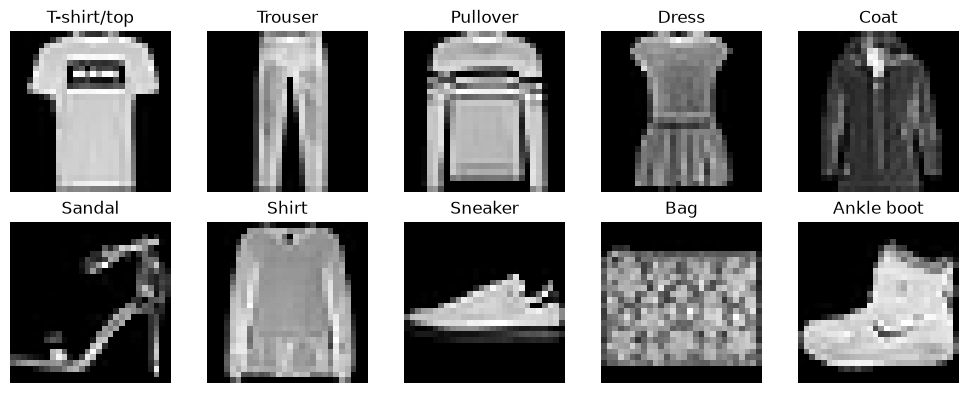

In [5]:
# Lista com os nomes das classes do conjunto de dados Fashion MNIST, na mesma ordem dos índices
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Dicionário para armazenar um exemplo por classe
examples = {}

# Itera sobre o dataset até obter um exemplo de cada classe
for img, label in training_data:
    if label not in examples:
        examples[label] = img.squeeze()  # remove o canal extra (1, 28, 28) -> (28, 28)
    if len(examples) == 10:
        break

# Plota os exemplos
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i], cmap="gray")
    plt.title(classes[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

### Criação dos DataLoaders

A seguir criaremos os DataLoaders para os dois conjuntos de dados (treino e teste). Utilizaremos um gerador de dados aleatórios independente para facilitar a reprodutibilidade do experimento.

In [ ]:
# Define um gerador de dados aleatórios específico para o dataloader, 
# assim deixamos explicito que o gerador de dados aleatórios do Dataloader
# é independente do gerador de dados aleatórios global do sistema (e do modelo).

data_generator = torch.Generator()
data_generator.manual_seed(SEED)

batch_size = 64                                                                                     # Define o tamanho do lote
train_dataloader = DataLoader(
    training_data, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True, 
    generator=data_generator)   # Cria o DataLoader para o conjunto de treinamento

# não precisa do generator, pois o test_data não é embaralhado
test_dataloader = DataLoader(
    test_data, 
    batch_size=batch_size)      # Cria o DataLoader para o conjunto de teste

# Itera sobre o DataLoader de teste para visualizar as formas dos dados
for X, y in test_dataloader:
    # Exibe a forma e o tipo do tensor de imagens
    # N = tamanho do lote, C = canais (1 para imagens em tons de cinza), H = altura, W = largura
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")

    # Exibe a forma e o tipo dos rótulos (labels)
    print(f"Forma de y [N, ] : {y.shape}, Tipo de dados em y: {y.dtype}")

    break  # Encerra o loop após a primeira iteração, apenas para inspeção dos dados

Forma de X [N, C, H, W]: torch.Size([64, 1, 28, 28]), Tipo de dados em X: torch.float32
Forma de y [N, ] : torch.Size([64]), Tipo de dados em y: torch.int64


## Definição das Redes Neurais

### Gerador

In [7]:
class Gerador(nn.Module):

    def __init__(self, z_dim=100, n_classes=10):
        super().__init__()
        self.z_dim = z_dim
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Linear(z_dim+n_classes, 7*7*128),
            nn.Unflatten(dim=1, unflattened_size=(128, 7, 7)),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(True),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x, labels):
        # Se labels contém índices de classe, converte para one-hot.
        # Isso vai permitir que o gerador use rotulos de treinamento (vetores) e rotulos de inferencia (one-hot).
        # No segundo caso não precisamos transformar em one-hot novamente.
        if labels.dim() == 1:
            labels = F.one_hot(
                labels,
                num_classes=self.n_classes
            ).float()

        # Concatena o vetor de ruído com o vetor de rótulos
        x = torch.cat((x, labels), dim=1)

        return self.net(x)

### Crítico

In [8]:
class Critico(nn.Module):

    def __init__(self, n_classes=10):
        super().__init__()
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Conv2d(1+n_classes, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(p=0.4),
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(p=0.4),
            nn.Flatten(),
            nn.Linear(7*7*128, 1),
        )

    def forward(self, x, labels):

        # Durante o treinamento, os rótulos chegam normalmente como índices inteiros,
        # por exemplo: [2, 5, 1, ...]. Nesse caso, convertemos cada índice para um
        # vetor one-hot com uma posição para cada uma das 10 classes.
        if labels.dim() == 1:
            labels = F.one_hot(
                labels,
                num_classes=self.n_classes
            ).float()

        # Neste ponto, cada rótulo é representado por um vetor com n_classes valores:
        #
        #   [batch_size, n_classes]
        #
        # Como a entrada do crítico é uma imagem, precisamos transformar esse vetor
        # em canais adicionais que tenham a mesma altura e largura da imagem.
        #
        # Primeiro adicionamos duas dimensões espaciais:
        #
        #   [batch_size, n_classes]
        #                ↓
        #   [batch_size, n_classes, 1, 1]
        labels = labels[:, :, None, None]

        # Em seguida, expandimos cada valor do vetor de classe por toda a imagem.
        #
        # Por exemplo, para a classe 2:
        #
        #   [0, 0, 1, 0, ..., 0]
        #
        # teremos 10 canais 28x28:
        # - canais 0, 1, 3, ..., 9 preenchidos com 0;
        # - canal 2 preenchido com 1.
        #
        # Assim:
        #
        #   [batch_size, n_classes, 1, 1]
        #                ↓
        #   [batch_size, n_classes, 28, 28]
        
        labels = labels.expand(
            -1,
            -1,
            x.shape[2], #   x tem shape (batch_size, 1, 28, 28)
            x.shape[3]  #   x tem shape (batch_size, 1, 28, 28)
        )

        # Agora concatenamos os canais que representam a classe com o canal da imagem.
        #
        # imagem (x):
        #   [batch_size, 1, 28, 28]
        #
        # classe (labels):
        #   [batch_size, 10, 28, 28]
        #
        # entrada final do crítico:
        #   [batch_size, 11, 28, 28]
        #
        x = torch.cat((x, labels), dim=1)

        return self.net(x)

## Treinamento

### Função de treinamento

Primeiro definimos a função responsável pelo treinamento do gerador e do crítico.

In [ ]:
def train_wgan(dataloader, gerador, critico, opt_gerador, opt_critico, device, epoch, z_dim, n_critic=5, clip_value=0.01):
    # Coloca o modelo em modo de treinamento
    gerador.train()
    critico.train()

    # Acumuladores usados para calcular as perdas médias da época.
    soma_perda_critico = 0.0
    soma_perda_gerador = 0.0
    num_passos_critico = 0

    # diferente do exemplo do professor, agora queremos os labels que o dataloader 
    # retorna para poder usar no treinamento condicional
    for batch, (real_data, labels) in enumerate(dataloader):
        batch_size = real_data.shape[0]
        real_data = real_data.to(device)
        labels = labels.to(device)

        # ========================================
        # Treinamento do CRÍTICO (n_critic vezes)
        # ========================================
        for _ in range(n_critic):
            # gera ruido aleatorio para o gerador
            z = torch.randn((batch_size, z_dim), device=device)
            # gera dados falsos com o gerador, adicionando os labels
            dados_falsos = gerador(z, labels).detach()

            # calcula a saida do critico para os dados reais e falsos, também usando os labels
            saida_reais = critico(real_data, labels)
            saida_falsos = critico(dados_falsos, labels)

            # calcula a perda do critico
            perda_critico = saida_falsos.mean() - saida_reais.mean()

            # calcula o gradiente da perda do critico
            opt_critico.zero_grad()
            perda_critico.backward()
            opt_critico.step()

            # Clipping dos pesos do crítico para satisfazer Lipschitz
            for p in critico.parameters():
                p.data.clamp_(-clip_value, clip_value)

            # Acumula todas as perdas dos passos do crítico.
            soma_perda_critico += perda_critico.item()
            num_passos_critico += 1            

        # ========================================
        # Treinamento do GERADOR (1 vez)
        # ========================================
        # gera ruido aleatorio para o gerador
        z = torch.randn((batch_size, z_dim), device=device)
        # gera dados falsos com o gerador, adicionando os labels
        dados_falsos = gerador(z, labels)
        # calcula a saida do critico para os dados falsos, também usando os labels
        saida_falsos = critico(dados_falsos, labels)

        # calcula a perda do gerador
        perda_gerador = -saida_falsos.mean()

        # calcula o gradiente da perda do gerador
        opt_gerador.zero_grad()
        perda_gerador.backward()
        opt_gerador.step()

        # Acumula uma perda do gerador para cada batch.
        soma_perda_gerador += perda_gerador.item()
        
        # ========================================
        # Log
        # ========================================
        if batch % 100 == 0 or batch == len(dataloader) - 1:
            print(
                f"[Época {epoch:03d}] "
                f"[Lote {batch:03d}/{len(dataloader)}] "
                f"Perda Crítico: {perda_critico.item():.4f} | "
                f"Perda Gerador: {perda_gerador.item():.4f}"
            )

    # Calcula as perdas médias da época.
    media_perda_critico = soma_perda_critico / num_passos_critico
    media_perda_gerador = soma_perda_gerador / len(dataloader)

    return media_perda_critico, media_perda_gerador

### Função de geração de dados a partir do gerador

Na sequencia, definimos uma função auxiliar que gera os dados a partir do gerador (em modo eval). Adaptamos a versão original do professor para suportar tanto a geração a partir de zeros (como no codigo original), quanto a utilização de labels e vetores latentes específicos. Tal flexibilidade foi adicionada para facilitar a criação de dados nas etapas posteriores ao treinamento, onde vamos querer gerar alguns vetores latentes específicos e trabalhar com eles.

In [ ]:
def gerar(gerador, device, z_dim=100, z=None, labels=None):
    # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
    gerador.eval()

    # Se nenhum vetor latente for fornecido, usa um vetor fixo de zeros, como na versão original do código do professor.
    if z is None:
        z = torch.zeros((1, z_dim), device=device)
    else:
        # se o vetor latente for fornecido, garante que ele esteja no mesmo dispositivo em que o modelo está sendo executado.
        z = z.to(device)

    # Se nenhum rótulo for fornecido, sorteia aleatoriamente uma classe.
    # Isso permite gerar uma imagem condicional sem precisar informar explicitamente o rótulo a cada chamada.
    if labels is None:
        labels = torch.randint(0, gerador.n_classes, (1,), device=device)
    else:
        labels = labels.to(device)

    # Desativa o cálculo de gradientes para economizar memória
    # e acelerar a execução, já que estamos apenas gerando imagens.
    with torch.no_grad():
        dados_falsos = gerador(z, labels)

    # Move o resultado para a CPU e converte para NumPy,
    # pois o matplotlib não plota tensores em MPS/GPU diretamente.
    dados_falsos = dados_falsos.cpu().numpy().reshape(28, 28)

    return dados_falsos

### Preparação dos modelos para executar o treinamento.

In [11]:
z_dim = 100
n_classes = len(classes)

# Inicializa os modelos
modelo_gerador = Gerador(z_dim, n_classes=n_classes)
# Inicializa os modelos
modelo_critico = Critico(n_classes=n_classes)

# tenta usar acelerador se disponível
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

modelo_gerador.to(device)
modelo_critico.to(device)

# Exibe qual dispositivo está sendo utilizado
print(f"Usando {device}.")

Usando mps.


### Exibe a arquitetura das redes do Gerador e do Critico.

In [12]:
# Cria entradas apenas para exibir o summary das redes
z_summary = torch.randn((1, z_dim), device=device)
label_summary = torch.tensor([0], device=device)

imagem_summary = torch.randn((1, 1, 28, 28), device=device)

In [13]:
# Gerador
print(modelo_gerador) # Imprime a arquitetura do modelo
summary(modelo_gerador, input_data=(z_summary, label_summary), device=device)

Gerador(
  (net): Sequential(
    (0): Linear(in_features=110, out_features=6272, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (7): Tanh()
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
Gerador                                  [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 1, 28, 28]            --
│    └─Linear: 2-1                       [1, 6272]                 696,192
│    └─Unflatten: 2-2                    [1, 128, 7, 7]            --
│    └─BatchNorm2d: 2-3                  [1, 128, 7, 7]            256
│    └─ConvTranspose2d: 2-4              [1, 64, 14, 14]           204,864
│    └─ReLU: 2-5                         [1, 64, 14, 14]           --
│    └─BatchNorm2d: 2-6                  [1, 64, 14, 14]           128
│    └─ConvTranspose2d: 2-7              [1, 1, 28, 28]            1,601
│    └─Tanh: 2-8                         [1, 1, 28, 28]            --
Total params: 903,041
Trainable params: 903,041
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 42.11
Input size (MB): 0.00
Forward/backward pass size (MB): 0.31
Params size (MB): 3.61
Estimated Tota

In [14]:
# Crítico
print(modelo_critico) # Imprime a arquitetura do modelo
summary(modelo_critico, input_data=(imagem_summary, label_summary), device=device)

Critico(
  (net): Sequential(
    (0): Conv2d(11, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.4, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.4, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=6272, out_features=1, bias=True)
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
Critico                                  [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Conv2d: 2-1                       [1, 64, 14, 14]           17,664
│    └─LeakyReLU: 2-2                    [1, 64, 14, 14]           --
│    └─Dropout: 2-3                      [1, 64, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 128, 7, 7]            204,928
│    └─LeakyReLU: 2-5                    [1, 128, 7, 7]            --
│    └─Dropout: 2-6                      [1, 128, 7, 7]            --
│    └─Flatten: 2-7                      [1, 6272]                 --
│    └─Linear: 2-8                       [1, 1]                    6,273
Total params: 228,865
Trainable params: 228,865
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 13.51
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.92
Estimated Total S

### Definição de Hiperparametros do treinamento.

In [15]:
# Otimizadores
lr_gerador = 1e-4   # taxa de aprendizagem do gerador
lr_critico = 1e-4   # taxa de aprendizagem do crítico
optimizador_gerador = torch.optim.RMSprop(modelo_gerador.parameters(), lr=lr_gerador)
optimizador_critico = torch.optim.RMSprop(modelo_critico.parameters(), lr=lr_critico)

# Hyper-parametros
clip_value = 0.01
n_critic = 5

### Execução do laço principal de treinamento

In [16]:
num_epochs = 100  # Define o número total de épocas (iterações completas sobre o conjunto de dados de treinamento)
evolucao_dado_falso = []
epocas_evolucao = []

historico_perda_critico = []
historico_perda_gerador = []

# Vetor latente fixo usado para acompanhar a evolução
# da mesma amostra durante todo o treinamento.
z_fixo = torch.randn((1, z_dim), device=device)

# Classe fixa usada junto com o vetor latente fixo.
classe_fixa = torch.tensor([0], device=device)

for epoca in range(1, num_epochs + 1):
    media_critico, media_gerador = train_wgan(
        dataloader=train_dataloader,
        gerador=modelo_gerador,
        critico=modelo_critico,
        opt_gerador=optimizador_gerador,
        opt_critico=optimizador_critico,
        device=device,
        epoch=epoca,
        z_dim=z_dim,
        n_critic=n_critic,
        clip_value=clip_value
    )
    historico_perda_critico.append(media_critico)
    historico_perda_gerador.append(media_gerador)

    if epoca % 5 == 0 or epoca == 1:
        evolucao_dado_falso.append(
            gerar(
                gerador=modelo_gerador,
                device=device,
                z=z_fixo,
                labels=classe_fixa
            )
        )

        epocas_evolucao.append(epoca)        
        
print("Fim!")  # Exibe mensagem final indicando que o treinamento terminou

[Época 001] [Lote 000/937] Perda Crítico: -0.2336 | Perda Gerador: -0.0339
[Época 001] [Lote 100/937] Perda Crítico: -3.6561 | Perda Gerador: -18.9876
[Época 001] [Lote 200/937] Perda Crítico: -1.9074 | Perda Gerador: -10.8462
[Época 001] [Lote 300/937] Perda Crítico: -2.9096 | Perda Gerador: 7.7823
[Época 001] [Lote 400/937] Perda Crítico: -0.1351 | Perda Gerador: 0.2561
[Época 001] [Lote 500/937] Perda Crítico: -0.9239 | Perda Gerador: -6.2880
[Época 001] [Lote 600/937] Perda Crítico: -0.0861 | Perda Gerador: -13.3720
[Época 001] [Lote 700/937] Perda Crítico: -0.5599 | Perda Gerador: -3.2973
[Época 001] [Lote 800/937] Perda Crítico: -0.4865 | Perda Gerador: -11.1565
[Época 001] [Lote 900/937] Perda Crítico: -0.4417 | Perda Gerador: -11.6829
[Época 001] [Lote 936/937] Perda Crítico: -0.2401 | Perda Gerador: -10.1330
[Época 002] [Lote 000/937] Perda Crítico: -0.4296 | Perda Gerador: -11.6626
[Época 002] [Lote 100/937] Perda Crítico: -0.4229 | Perda Gerador: -12.0910
[Época 002] [Lote 2

## Resultados

### Geração de dados aleatórios e visualização preliminar

A seguir geramos alguns resultados aleatorios para uma avaliação preliminar do resultado obtido com o treinamento.

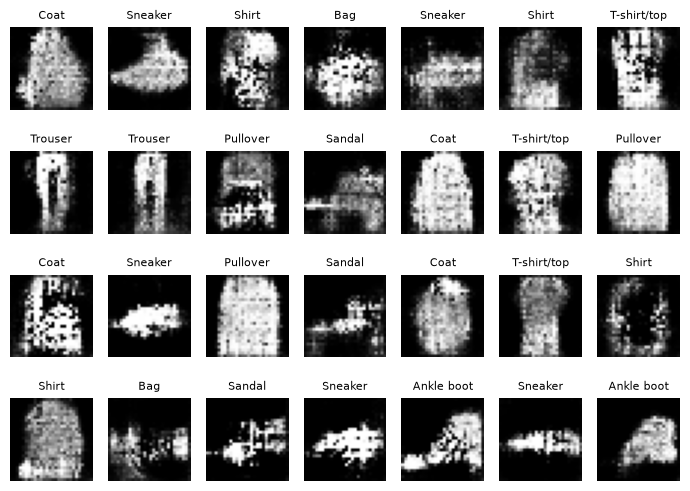

In [17]:
# Define a função de gerar dados falsos de um vetores latentes aleatorios
def gerar_aleatorio(gerador, device, z_dim=100, n_images=20, labels=None):
    # Coloca o modelo em modo de avaliação
    gerador.eval()

    # Gera n_images vetores latentes aleatórios
    z = torch.randn((n_images, z_dim), device=device)

    # Se nenhum rótulo for fornecido, sorteia aleatoriamente
    # uma classe para cada imagem do lote.
    if labels is None:
        labels = torch.randint(0, gerador.n_classes, (n_images,), device=device)
    else:
        labels = labels.to(device)

    # Desativa o cálculo de gradientes, pois estamos apenas
    # gerando imagens para visualização.
    with torch.no_grad():
        dados_falsos = gerador(z, labels).detach().cpu().numpy()

    return dados_falsos, labels.cpu().numpy()

# Função para plotar várias imagens em um grid, exibindo
# também a classe usada para gerar cada imagem.
def plot_multiple_images(imagens, labels, classes, n_cols=7):

    n_rows = (len(imagens) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.3))
    for index, (img, label) in enumerate(zip(imagens, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(img.reshape(28, 28), cmap="gray")
        # Exibe o nome da classe correspondente ao rótulo.
        plt.title(classes[int(label)], fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Gera um lote com imagens falsas
imagens, labels = gerar_aleatorio(
    modelo_gerador,
    device,
    z_dim=z_dim,
    n_images=28
)

# Chama a função para plotar as imagens
plot_multiple_images(
    imagens,
    labels,
    classes,
    n_cols=7
)

### Curvas de perda do Gerador e do Crítico ao longo das épocas 

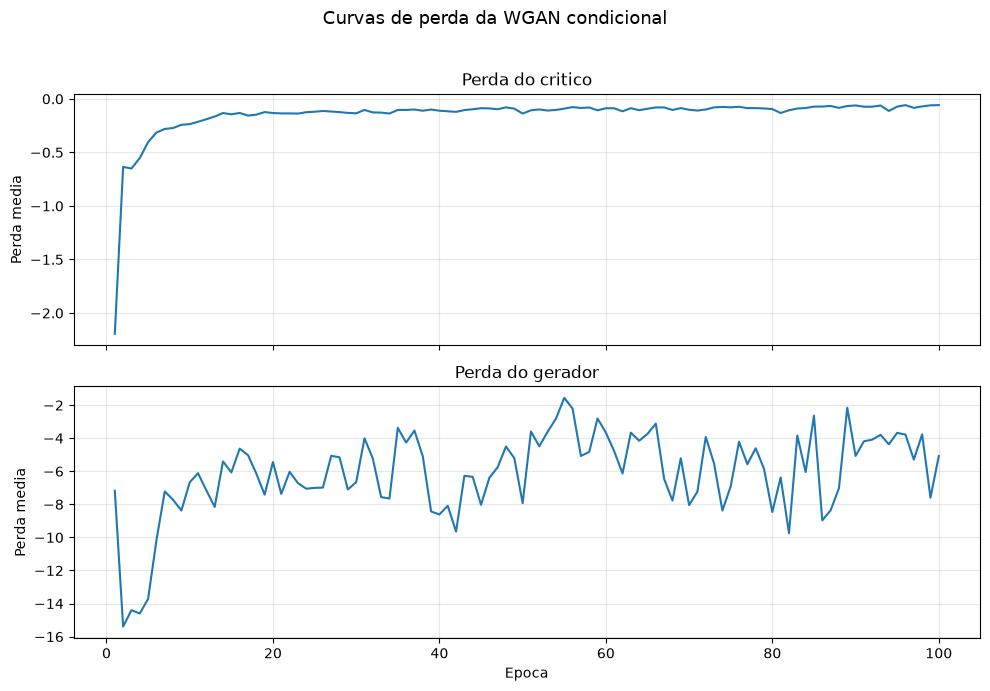

In [30]:
# Gera o eixo X correspondente as epocas do treinamento.
epocas = range(1, len(historico_perda_gerador) + 1)

# Cria dois graficos, um para cada rede, permitindo visualizar
# adequadamente as diferentes escalas das perdas.
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True
)

# Plota a perda media do critico ao longo das epocas.
axes[0].plot(
    epocas,
    historico_perda_critico
)

axes[0].set_title("Perda do critico")
axes[0].set_ylabel("Perda media")
axes[0].grid(True, alpha=0.3)

# Plota a perda media do gerador ao longo das epocas.
axes[1].plot(
    epocas,
    historico_perda_gerador
)

axes[1].set_title("Perda do gerador")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Perda media")
axes[1].grid(True, alpha=0.3)

# Adiciona um titulo geral para os dois graficos.
fig.suptitle(
    "Curvas de perda da WGAN condicional",
    fontsize=13
)

# Ajusta o espacamento entre os elementos.
plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

### Evolução das saídas do gerador para um vetor latente fixo durante o treinamento

Agora vamos mostrar a evolução de um vetor latente fixado no inicio do treinamento e exibir sua evolução ao longo das épocas.

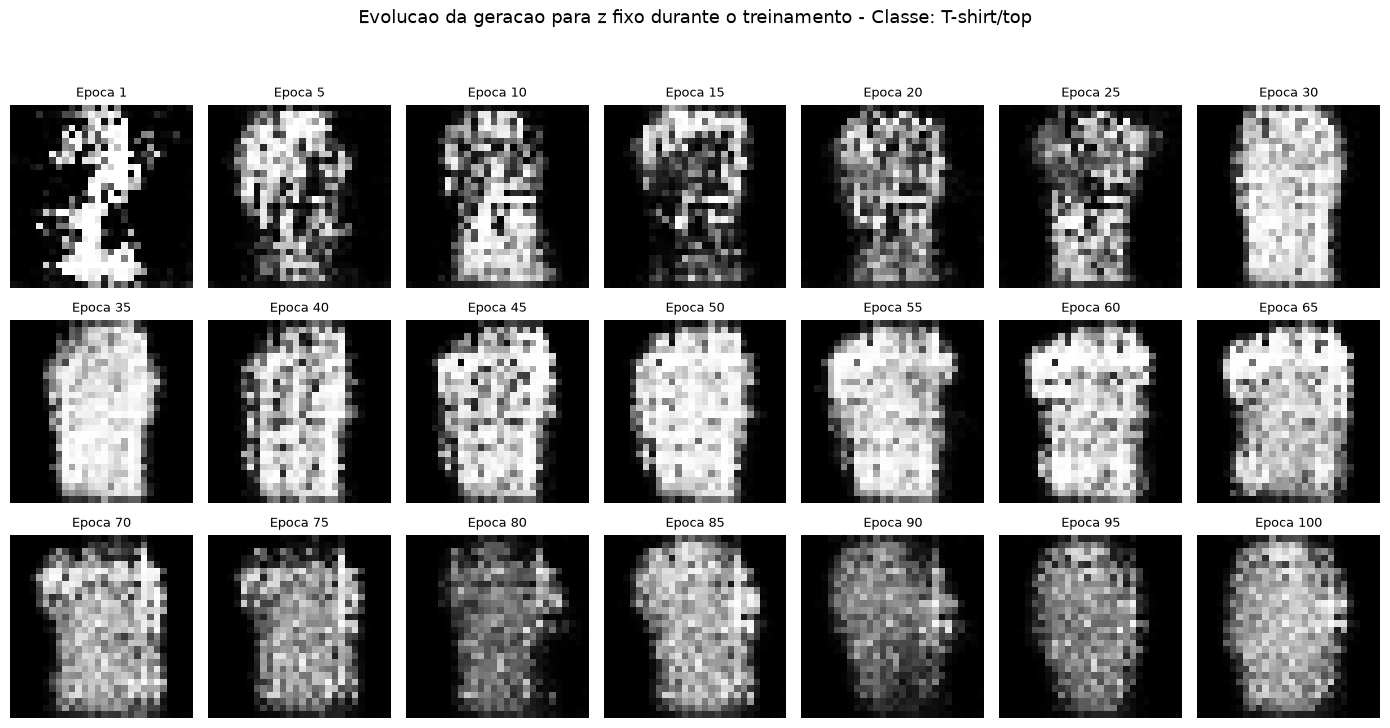

In [56]:
# Lista com as imagens geradas para o mesmo vetor latente
# e a mesma classe em diferentes epocas do treinamento.
imagens = evolucao_dado_falso

# Define a quantidade de colunas da grade.
# Como temos 21 imagens (epocas 1, 5, 10, ..., 100),
# 7 colunas produzem uma grade com 3 linhas.
n_cols = 7

# Calcula automaticamente a quantidade de linhas necessaria
# para acomodar todas as imagens.
n_rows = (len(imagens) - 1) // n_cols + 1

# Cria a figura e os subplots onde cada imagem sera exibida.
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, n_rows * 2.5)
)

# Ajusta o espacamento entre os subplots e reserva
# espaco superior para o titulo geral.
plt.subplots_adjust(
    top=0.90,
    hspace=0.35,
    wspace=0.15
)

# Converte a matriz de eixos em um vetor unidimensional.
# Isso facilita percorrer todos os subplots em um unico loop.
axes = np.array(axes).reshape(-1)

# Percorre simultaneamente:
# - cada subplot;
# - cada imagem gerada;
# - a epoca correspondente.
for ax, img, epoca in zip(axes, imagens, epocas_evolucao):

    # Exibe a imagem usando sempre a mesma escala de valores.
    # Como a saida do gerador usa Tanh, os pixels estao no intervalo [-1, 1].
    # Fixar vmin e vmax evita que o matplotlib ajuste o contraste
    # individualmente para cada imagem.
    ax.imshow(
        img,
        cmap="gray",
        vmin=-1,
        vmax=1
    )

    # Exibe acima de cada imagem a epoca em que ela foi gerada.
    ax.set_title(
        f"Epoca {epoca}",
        fontsize=9
    )

    # Remove os eixos para deixar apenas a imagem visivel.
    ax.axis("off")

# Caso a quantidade de subplots seja maior que a quantidade
# de imagens, oculta os subplots que ficaram sem uso.
for ax in axes[len(imagens):]:
    ax.axis("off")

# Adiciona um titulo geral indicando que o vetor latente z
# e a classe foram mantidos fixos durante toda a evolucao.
fig.suptitle(
    f"Evolucao da geracao para z fixo durante o treinamento - Classe: {classes[classe_fixa.item()]}",
    fontsize=13
)

# Ajusta automaticamente o espacamento entre os elementos.
# O parametro rect reserva espaco superior para o titulo geral.
plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()

### Geração de grade de amostras para as classes

In [41]:
# Gera e plota uma grade com uma classe por linha.
# A primeira coluna mostra uma imagem real de referencia,
# e as demais colunas mostram amostras geradas para a mesma classe.
def plotar_grade_por_classe(
    gerador,
    classes,
    exemplos_reais,
    device,
    z_dim=100,
    n_cols_geradas=7
):
    # Coloca o gerador em modo de avaliacao.
    gerador.eval()

    n_classes = len(classes)

    # Numero total de colunas:
    # 1 coluna para a imagem real + n_cols_geradas para imagens geradas.
    n_cols_total = 1 + n_cols_geradas

    # Cria uma grade com uma linha por classe.
    fig, axes = plt.subplots(
        n_classes,
        n_cols_total,
        figsize=(n_cols_total * 1.5, n_classes * 1.5)
    )

    # Garante que axes seja tratado como matriz 2D.
    axes = np.array(axes).reshape(n_classes, n_cols_total)

    # Nao calcula gradientes, pois estamos apenas gerando imagens.
    with torch.no_grad():

        # Percorre todas as classes do Fashion-MNIST.
        for classe_idx, nome_classe in enumerate(classes):

            # =========================
            # Coluna 0: imagem real
            # =========================

            # Recupera a imagem real de referencia da classe atual.
            img_real = exemplos_reais[classe_idx]

            # Converte da faixa [-1, 1] para [0, 1] para visualizacao.
            img_real_plot = (img_real + 1.0) / 2.0

            axes[classe_idx, 0].imshow(
                img_real_plot,
                cmap="gray",
                vmin=0,
                vmax=1
            )
            axes[classe_idx, 0].axis("off")

            # =========================
            # Colunas seguintes: imagens geradas
            # =========================

            # Gera varios vetores latentes aleatorios para produzir
            # varias amostras da mesma classe.
            z = torch.randn((n_cols_geradas, z_dim), device=device)

            # Cria um vetor de labels contendo a mesma classe repetida
            # para todas as imagens geradas da linha atual.
            labels = torch.full(
                (n_cols_geradas,),
                classe_idx,
                device=device,
                dtype=torch.long
            )

            # Gera as imagens condicionadas pela classe atual.
            imagens_geradas = gerador(z, labels).cpu().numpy()

            # Exibe as imagens geradas nas colunas 1 em diante.
            for col in range(n_cols_geradas):
                img = imagens_geradas[col].reshape(28, 28)

                # Converte da faixa [-1, 1] para [0, 1].
                img_plot = (img + 1.0) / 2.0

                axes[classe_idx, col + 1].imshow(
                    img_plot,
                    cmap="gray",
                    vmin=0,
                    vmax=1
                )
                axes[classe_idx, col + 1].axis("off")

            # Exibe o nome da classe a esquerda da primeira imagem da linha.
            # Usamos text() em vez de set_ylabel(), pois axis("off")
            # tambem ocultaria o rotulo do eixo.
            axes[classe_idx, 0].text(
                -0.15,                       # Posicao horizontal, a esquerda da imagem
                0.5,                         # Centro vertical da imagem
                nome_classe,
                transform=axes[classe_idx, 0].transAxes,
                ha="right",
                va="center",
                fontsize=10,
                fontweight="bold",
                clip_on=False
            )

    # Coloca titulos apenas na primeira linha para identificar
    # claramente a coluna real e as colunas geradas.
    axes[0, 0].set_title("Real", fontsize=10)

    for col in range(1, n_cols_total):
        axes[0, col].set_title(f"Gerada {col}", fontsize=10)

    fig.suptitle(
        "Grade de amostras por classe: referencia real e imagens geradas",
        fontsize=13
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [42]:
# Seleciona uma imagem real de referencia para cada classe.
def obter_exemplos_reais(dataset, n_classes):
    exemplos_reais = {}

    for img, label in dataset:
        if label not in exemplos_reais:
            exemplos_reais[label] = img.squeeze().cpu().numpy()

        if len(exemplos_reais) == n_classes:
            break

    return exemplos_reais

exemplos_reais = obter_exemplos_reais(
    training_data,
    n_classes=len(classes)
)

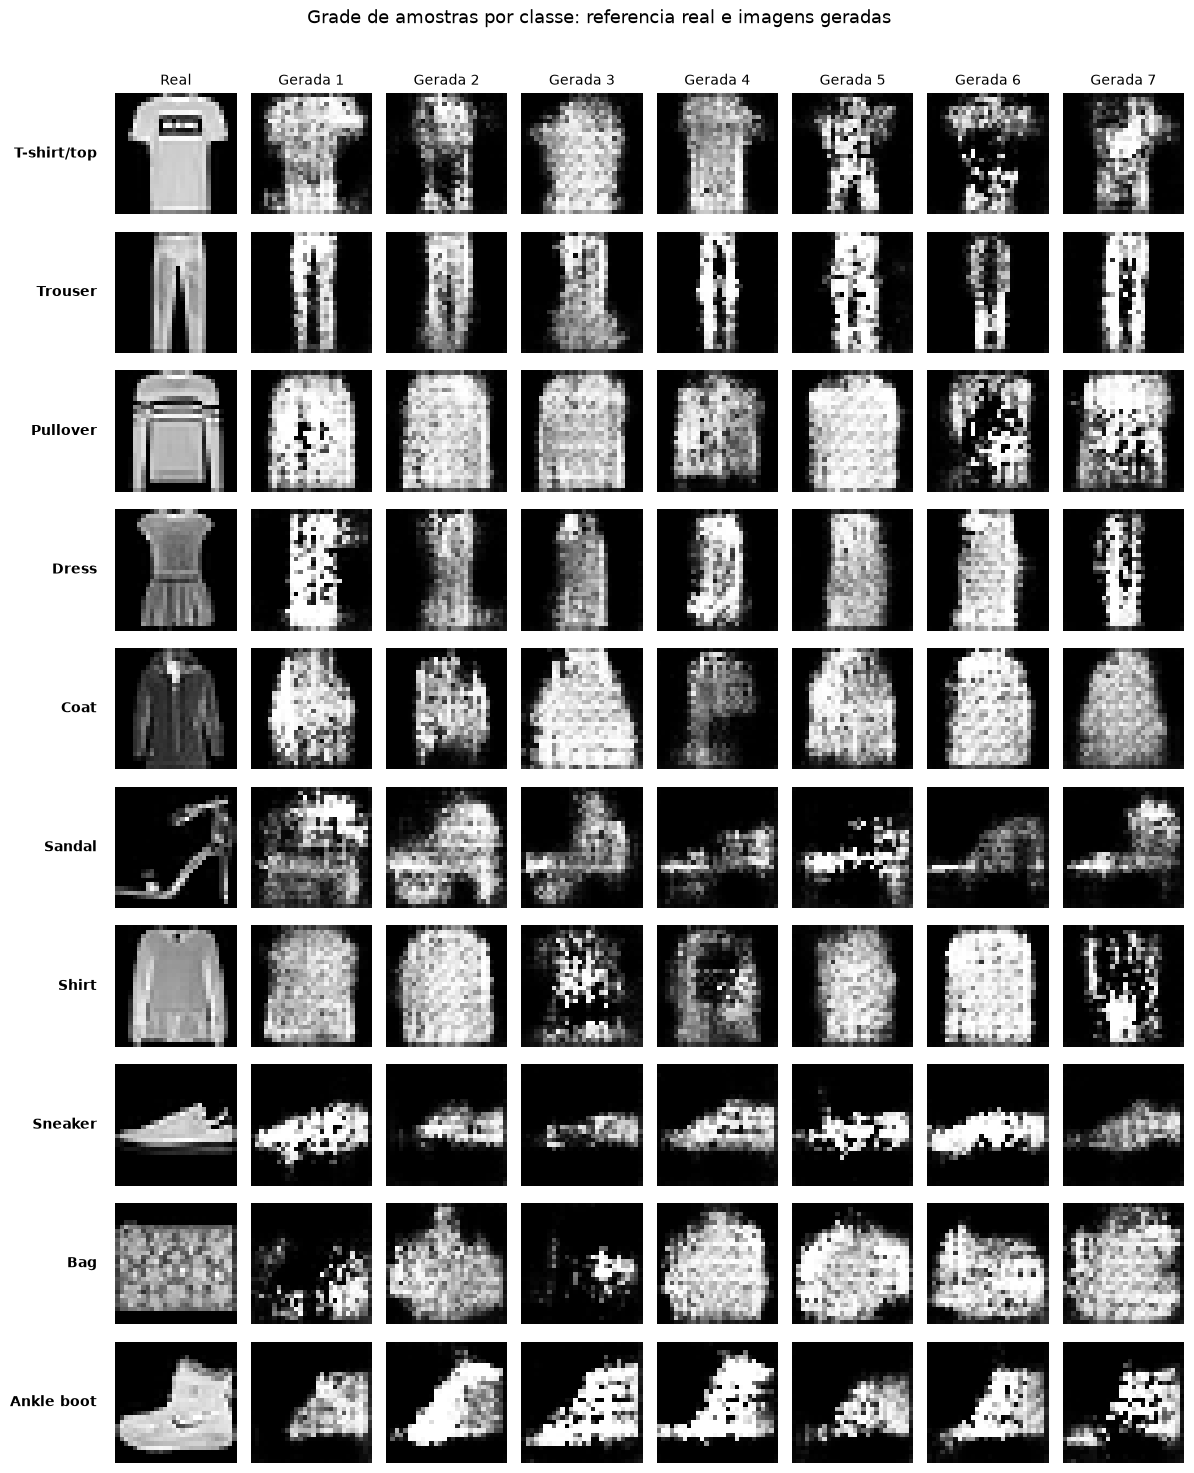

In [43]:
plotar_grade_por_classe(
    gerador=modelo_gerador,
    classes=classes,
    exemplos_reais=exemplos_reais,
    device=device,
    z_dim=z_dim,
    n_cols_geradas=7
)

## Interpolações no espaço latente

### Funções auxiliares

Primeiro definimos uma função auxiliar que permitirar plotar as interpolações utilizando o mesmo formato.

In [ ]:
# Funcao para plotar uma lista de imagens em uma unica linha.
def plotar_imagens(imagens, titulo=None):

    fig, eixos = plt.subplots(
        1,
        len(imagens),
        figsize=(len(imagens), 1.5)
    )

    # Se houver apenas uma imagem, garante que eixos seja iteravel.
    if len(imagens) == 1:
        eixos = [eixos]
        
    # Exibe as imagens na ordem em que foram geradas,
    # permitindo visualizar a transicao ao longo da interpolacao.
    for ax, img in zip(eixos, imagens):
        ax.imshow(img.reshape(28, 28), cmap="gray")
        ax.axis("off")

    # Adiciona um titulo opcional para identificar
    # o experimento de interpolacao realizado.
    if titulo is not None:
        fig.suptitle(titulo)

    plt.tight_layout()
    plt.show()

### Interpolação do vetor latente z fixo variando entre duas classes

In [46]:
# Funcao que interpola entre duas classes, mantendo o vetor latente z fixo.
def interpolar_classes(gerador, c1, c2, n_classes, device, z_dim=100, steps=10, z=None):

    # Se nenhum vetor latente for fornecido, gera um vetor aleatorio.
    # Esse mesmo vetor sera mantido fixo durante toda a interpolacao.
    if z is None:
        z = torch.randn((1, z_dim), device=device)
    else:
        z = z.to(device)

    # Cria os vetores one-hot das duas classes extremas.
    # Exemplo:
    # c1 = 7 -> [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
    # c2 = 9 -> [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
    label_c1 = F.one_hot(
        torch.tensor([c1], device=device),
        num_classes=n_classes
    ).float()

    label_c2 = F.one_hot(
        torch.tensor([c2], device=device),
        num_classes=n_classes
    ).float()

    # Gera os valores de alpha no intervalo [0, 1].
    # Cada alpha define um ponto intermediario entre c1 e c2.
    alpha_valores = torch.linspace(0, 1, steps).to(device)

    imagens_interpoladas = []

    # Para cada valor de alpha, interpola entre os dois vetores one-hot
    # e gera a imagem correspondente usando sempre o mesmo z.
    for alpha in alpha_valores:

        # Interpolacao linear entre as classes:
        # alpha = 0   -> classe c1
        # alpha = 1   -> classe c2
        # valores intermediarios -> mistura entre c1 e c2
        label_interp = (1 - alpha) * label_c1 + alpha * label_c2

        # Gera uma imagem usando o mesmo z fixo e o rotulo interpolado.
        imagem = gerar(
            gerador=gerador,
            device=device,
            z=z,
            labels=label_interp
        )

        imagens_interpoladas.append(imagem)

    return imagens_interpoladas

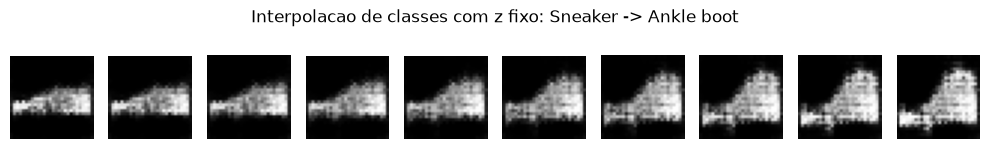

In [48]:
# Escolhe duas classes para interpolar.
c1 = 7  # Sneaker
c2 = 9  # Ankle boot

# Gera as imagens interpoladas.
imagens = interpolar_classes(
    gerador=modelo_gerador,
    c1=c1,
    c2=c2,
    n_classes=n_classes,
    device=device,
    z_dim=z_dim,
    steps=10
)

# Plota as imagens lado a lado.
plotar_imagens(
    imagens,
    titulo=f"Interpolacao de classes com z fixo: {classes[c1]} -> {classes[c2]}"
)

### Interpolação com classe fixa e variação do vetor latente de z1 a z2

In [24]:
# Interpola linearmente entre dois vetores latentes, mantendo a classe fixa durante toda a interpolacao.
def interpolar_z(
    gerador,
    classe,
    z_dim=100,
    steps=10,
    device="cpu"
):
    # Gera dois vetores latentes aleatorios que representam
    # os extremos da interpolacao.
    z1 = torch.randn((1, z_dim), device=device)
    z2 = torch.randn((1, z_dim), device=device)

    # Cria o rotulo da classe que sera mantida fixa durante
    # toda a interpolacao.
    label = torch.tensor([classe], device=device)

    # Coloca o gerador em modo de avaliacao.
    gerador.eval()

    # Valores de alpha entre 0 e 1 determinam os pontos
    # intermediarios entre z1 e z2.
    alpha_valores = torch.linspace(
        0,
        1,
        steps,
        device=device
    )

    imagens_interpoladas = []

    # Nao precisamos calcular gradientes, pois estamos apenas
    # gerando imagens para visualizacao.
    with torch.no_grad():

        for alpha in alpha_valores:

            # Interpolacao linear entre os dois vetores latentes:
            #
            # alpha = 0 -> z_interp = z1
            # alpha = 1 -> z_interp = z2
            #
            # Valores intermediarios produzem combinacoes lineares
            # entre os dois pontos do espaco latente.
            z_interp = (1 - alpha) * z1 + alpha * z2

            # Gera uma imagem usando o vetor latente interpolado,
            # mantendo sempre a mesma classe.
            imagem_gerada = gerador(z_interp, label)

            # Move o resultado para CPU e converte para NumPy
            # para posterior visualizacao com matplotlib.
            imagens_interpoladas.append(
                imagem_gerada.squeeze().cpu().numpy()
            )

    return imagens_interpoladas

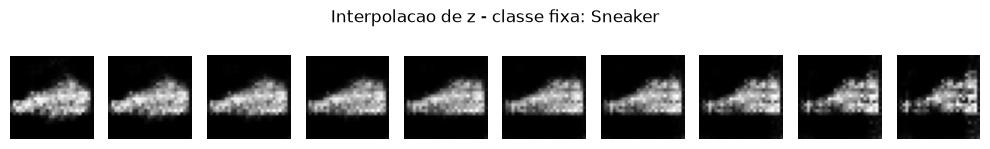

In [28]:
# Escolhe a classe que sera mantida fixa durante a interpolacao.
classe = 7  # Exemplo: Sneaker

# Gera imagens interpoladas entre z1 e z2, mantendo a classe fixa.
imagens = interpolar_z(
    gerador=modelo_gerador,
    classe=classe,
    z_dim=z_dim,
    steps=10,
    device=device
)

# Plota as imagens lado a lado.
plotar_imagens(
    imagens,
    titulo=f"Interpolacao de z - classe fixa: {classes[classe]}"
)

### Interpolação simultânea entre [z1, c1] e [z2, c2]

In [49]:
# Funcao que interpola simultaneamente entre dois vetores latentes
# e duas classes, gerando as imagens correspondentes.
def interpolar_z_e_classes(gerador, c1, c2, n_classes, device, z_dim=100, steps=10, z1=None, z2=None):

    # Se os vetores latentes nao forem fornecidos, gera dois vetores aleatorios.
    if z1 is None:
        z1 = torch.randn((1, z_dim), device=device)
    else:
        z1 = z1.to(device)

    if z2 is None:
        z2 = torch.randn((1, z_dim), device=device)
    else:
        z2 = z2.to(device)

    # Cria os vetores one-hot das duas classes extremas.
    label_c1 = F.one_hot(
        torch.tensor([c1], device=device),
        num_classes=n_classes
    ).float()

    label_c2 = F.one_hot(
        torch.tensor([c2], device=device),
        num_classes=n_classes
    ).float()

    # Valores de interpolacao no intervalo [0, 1].
    alpha_valores = torch.linspace(0, 1, steps).to(device)

    imagens_interpoladas = []

    # Para cada alpha, interpola simultaneamente:
    # - o vetor latente: z1 -> z2
    # - o vetor de classe: c1 -> c2
    for alpha in alpha_valores:

        # Interpola linearmente entre os vetores latentes.
        z_interp = (1 - alpha) * z1 + alpha * z2

        # Interpola linearmente entre os vetores one-hot das classes.
        label_interp = (1 - alpha) * label_c1 + alpha * label_c2

        # Gera a imagem correspondente ao ponto interpolado.
        imagem = gerar(
            gerador=gerador,
            device=device,
            z=z_interp,
            labels=label_interp
        )

        imagens_interpoladas.append(imagem)

    return imagens_interpoladas

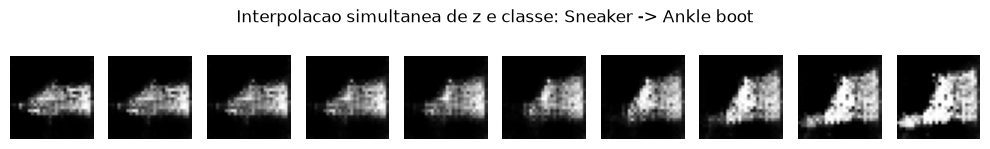

In [52]:
# Escolhe duas classes para interpolar simultaneamente.
c1 = 7  # Sneaker
c2 = 9  # Ankle boot

# Gera as imagens interpoladas.
imagens = interpolar_z_e_classes(
    gerador=modelo_gerador,
    c1=c1,
    c2=c2,
    n_classes=n_classes,
    device=device,
    z_dim=z_dim,
    steps=10
)

# Plota as imagens lado a lado.
plotar_imagens(
    imagens,
    titulo=f"Interpolacao simultanea de z e classe: {classes[c1]} -> {classes[c2]}"
)

## Fixação de vetor latente z e variação por todas as classes

In [54]:
# Gera uma imagem para cada classe usando sempre o mesmo vetor latente z.
def gerar_z_fixo_por_classe(gerador, device, n_classes, z_dim=100, z=None):

    # Se nenhum vetor latente for fornecido, gera um vetor aleatorio.
    # Esse mesmo vetor sera reutilizado para todas as classes.
    if z is None:
        z = torch.randn((1, z_dim), device=device)
    else:
        z = z.to(device)

    imagens = []

    # Percorre todas as classes, alterando apenas o rotulo.
    for classe in range(n_classes):

        # Cria o rotulo correspondente a classe atual.
        label = torch.tensor(
            [classe],
            device=device
        )

        # Gera a imagem usando sempre o mesmo z,
        # variando exclusivamente o rotulo da classe.
        imagem = gerar(
            gerador=gerador,
            device=device,
            z=z,
            labels=label
        )

        imagens.append(imagem)

    return imagens

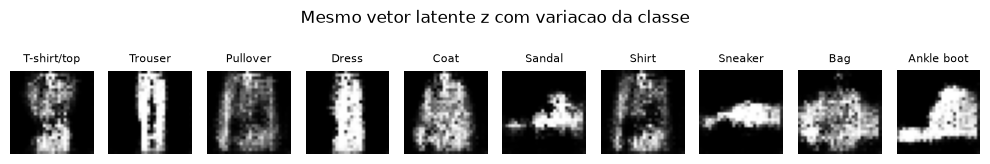

In [55]:
# Gera uma imagem para cada uma das 10 classes
# mantendo o mesmo vetor latente z.
imagens = gerar_z_fixo_por_classe(
    gerador=modelo_gerador,
    device=device,
    n_classes=n_classes,
    z_dim=z_dim
)

# Cria uma linha com uma imagem para cada classe.
fig, eixos = plt.subplots(
    1,
    n_classes,
    figsize=(n_classes, 1.8)
)

# Exibe cada imagem junto com o nome da classe correspondente.
for classe, (ax, img) in enumerate(zip(eixos, imagens)):
    ax.imshow(
        img.reshape(28, 28),
        cmap="gray"
    )

    ax.set_title(
        classes[classe],
        fontsize=8
    )

    ax.axis("off")

# Adiciona um titulo geral indicando que apenas o rotulo foi alterado.
fig.suptitle(
    "Mesmo vetor latente z com variacao da classe",
    fontsize=12
)

plt.tight_layout()
plt.show()